In [3]:
# Ejercicio

In [4]:
!pip install tensorflow numpy pillow matplotlib


In [5]:
!pip install kagglehub

In [6]:
from kagglehub import dataset_download

dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")

print("Ruta del dataset:", dataset_path)

100%|██████████| 43.4M/43.4M [00:00<00:00, 137MB/s]

Extracting files...


Ruta del dataset: /root/.cache/kagglehub/datasets/saumyamohandas/garbage-classification-image-dataset/versions/1


In [7]:
import os

for folder in os.listdir(dataset_path):
    print(folder)

dataset


In [8]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
)

class_names = train_ds.class_names
print(class_names)

Found 2972 files belonging to 1 classes.
['dataset']


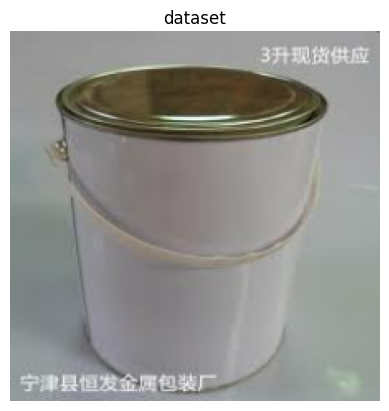

In [9]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
  plt.imshow(images[0].numpy().astype("uint8"))
  plt.title(class_names[labels[0]])
  plt.axis("off")

PASO 2 IMPORTAR LIBRERIRAS

In [10]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

PASO 3. AJUSTAR LA RUTA DEL DATASET

PASO 4. CARGAR IMAGENES

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

#Define DATA_DIR el path de kagglehub download
DATA_DIR = os.path.join(dataset_path, 'dataset')

train_data_path = os.path.join(DATA_DIR, 'Training')
val_data_path = os.path.join(DATA_DIR, 'Testing')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_path,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_data_path,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Clases detectadas:", class_names)

Found 2508 files belonging to 6 classes.
Found 464 files belonging to 6 classes.
Clases detectadas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


PASO 5 VER ALGUNAS IMAGENES

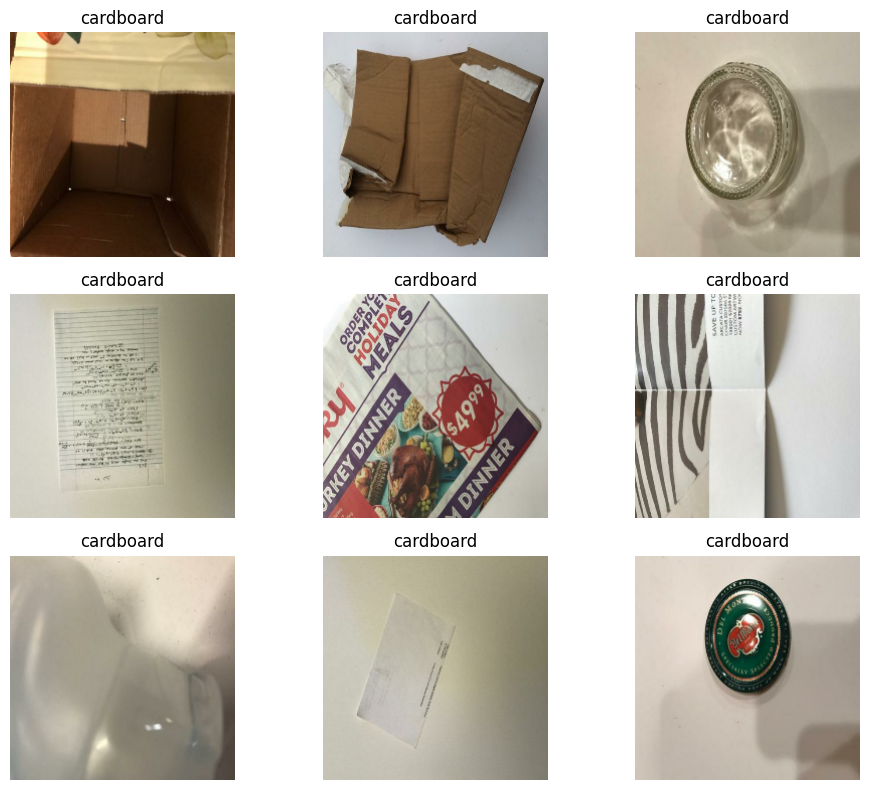

In [12]:
plt.figure(figsize=(10, 8))
for images, label in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

PASO 6 PREPARAR EL DATASET

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)